# Non-Hierarchical Multifidelity Triangular Maps Tutorial

This notebook is a compact, end-to-end introduction to the `NonHierarchicalTriangularMap` API. We learn a monotone lower-triangular map $\widehat{\boldsymbol{S}}^{\mathrm{NH}}$ that pushes a high-fidelity banana target density $\pi_0$
to a standard Gaussian reference $\eta$. This high-fidelity map is learned using samples from $\pi_0$ as well as samples from related lower-fidelity densities $\pi_1$ and $\pi_2$.


## Notation used in this notebook

 We use
$\ell=0$ for the high-fidelity target $\pi_0$ and
$\ell=1,\ldots,M$ for lower-fidelity targets. `X_ell[ell]` represents
$\mathcal X_\ell=\{x_\ell^{(j)}\}_{j=1}^{N_\ell}$, and `S_hat_NH` is the learned non-hierarchical map $\widehat{\boldsymbol{S}}^{\mathrm{NH}}$. Training proceeds in two stages: independently pretrain each low-fidelity $\widehat{\boldsymbol{S}}_\ell$, then
jointly train the high-fidelity shift $\delta_k$, scale coefficients
$\rho_{\ell,k}^{\mathrm{nm}},\rho_{\ell,k}^{\mathrm m}$, and correction
parameters $\theta_{\ell,k}^{\mathrm{corr}}$. In the API,
`shift_order`, constant `scale_order=0`, and `correction_order` select these
three pieces of the parameterization.

## 1. Imports and preliminary settings

In [1]:
import time

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np

from mftt import MapParams, OptimizationParams

SEED = 101
rng = np.random.default_rng(SEED)
INPUT_DIM = 2

TARGET_COLOR = "#E76F51"
REFERENCE_COLOR = "#457B9D"
LEARNED_COLOR = "#2A9D8F"
ALTERNATE_COLOR = "#8E5EA2"
MIDDLE_FIDELITY_COLOR = "#43AA8B"
LOW_FIDELITY_COLOR = "#6A77E9"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "font.size": 10,
})

from mftt import NonHierarchicalMapParams, NonHierarchicalTriangularMap


## 2. Sampling and density helpers

All helper names, batch conventions, and plotting helpers match the single-fidelity tutorial.


In [2]:
def banana_sample(n_samples, rng, scale_x=1.0, bend=0.5):
    """Draw samples from an analytic banana target."""
    z = rng.standard_normal((n_samples, 2))
    return S_ell_inverse(z, scale_x=scale_x, bend=bend)


def S_ell(x, scale_x=1.0, bend=0.5):
    """Map banana samples to the standard-Gaussian reference."""
    x = np.asarray(x, dtype=float)
    z = x.copy()
    z[:, 0] = x[:, 0] / scale_x
    z[:, 1] = x[:, 1] - bend * (z[:, 0] ** 2 - 1.0)
    return z


def S_ell_inverse(z, scale_x=1.0, bend=0.5):
    """Map standard-Gaussian samples to the banana target."""
    z = np.asarray(z, dtype=float)
    x = z.copy()
    x[:, 0] = scale_x * z[:, 0]
    x[:, 1] = z[:, 1] + bend * (z[:, 0] ** 2 - 1.0)
    return x


def standard_normal_logpdf(z):
    z = np.asarray(z, dtype=float)
    return -0.5 * np.sum(z * z, axis=1) - np.log(2.0 * np.pi)


def banana_logpdf(x, scale_x=1.0, bend=0.5):
    return standard_normal_logpdf(S_ell(x, scale_x=scale_x, bend=bend)) - np.log(scale_x)


def normal_pdf_1d(values, mean=0.0, std=1.0):
    values = np.asarray(values, dtype=float)
    scaled = (values - mean) / std
    return np.exp(-0.5 * scaled * scaled) / (np.sqrt(2.0 * np.pi) * std)


def make_grid(x_limits, y_limits, n=220):
    x1 = np.linspace(*x_limits, n)
    x2 = np.linspace(*y_limits, n)
    xx, yy = np.meshgrid(x1, x2)
    return xx, yy, np.column_stack((xx.ravel(), yy.ravel()))


def style_joint_axis(ax, x_label=r"$x_1$", y_label=r"$x_2$", limits=(-4.0, 4.0, -4.5, 4.5)):
    ax.set(xlabel=x_label, ylabel=y_label, xlim=limits[:2], ylim=limits[2:])
    ax.set_aspect("equal", adjustable="box")


## 3. Target and reference at a glance


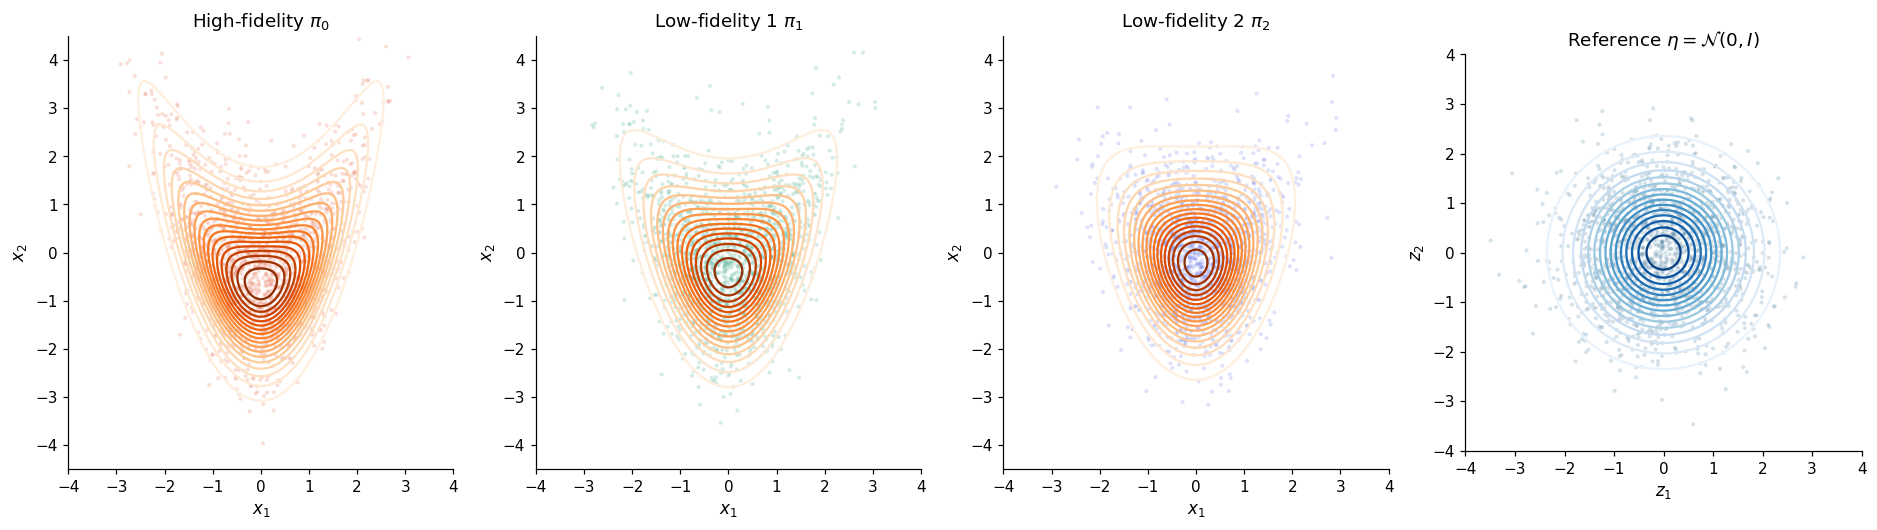

In [4]:
FIDELITY_PARAMS = [
    {"scale_x": 1.05, "bend": 0.65},
    {"scale_x": 0.95, "bend": 0.42},
    {"scale_x": 0.85, "bend": 0.22},
]
FIDELITY_NAMES = ["High-fidelity $\pi_0$", "Low-fidelity 1 $\pi_1$", "Low-fidelity 2 $\pi_2$"]
FIDELITY_COLORS = [TARGET_COLOR, MIDDLE_FIDELITY_COLOR, LOW_FIDELITY_COLOR]

N_ell = [4000, 5000, 6000]
N_test = 6000
N_display = 1500
X_ell = [banana_sample(n, rng, **params) for n, params in zip(N_ell, FIDELITY_PARAMS)]
x_0_test = banana_sample(N_test, rng, **FIDELITY_PARAMS[0])
z_reference_display = rng.standard_normal((N_display, INPUT_DIM))

x_xx, x_yy, x_grid = make_grid((-4.5, 4.5), (-4.5, 4.5))
z_xx, z_yy, z_grid = make_grid((-4.0, 4.0), (-4.0, 4.0))
true_target_densities = [
    np.exp(banana_logpdf(x_grid, **params)).reshape(x_xx.shape)
    for params in FIDELITY_PARAMS
]
reference_density = np.exp(standard_normal_logpdf(z_grid)).reshape(z_xx.shape)

assert np.allclose(
    S_ell_inverse(S_ell(x_0_test[:128], **FIDELITY_PARAMS[0]), **FIDELITY_PARAMS[0]),
    x_0_test[:128],
)
fig, axes = plt.subplots(1, 4, figsize=(17, 4.6), constrained_layout=True)
for axis, density, samples, title, color in zip(
    axes[:3], true_target_densities, X_ell, FIDELITY_NAMES, FIDELITY_COLORS
):
    axis.contour(x_xx, x_yy, density, levels=18, cmap="Oranges")
    axis.scatter(samples[:N_display, 0], samples[:N_display, 1], s=7, alpha=0.22, color=color, edgecolors="none")
    axis.set_title(title)
    style_joint_axis(axis)
axes[3].contour(z_xx, z_yy, reference_density, levels=18, cmap="Blues")
axes[3].scatter(z_reference_display[:, 0], z_reference_display[:, 1], s=7, alpha=0.22, color=REFERENCE_COLOR, edgecolors="none")
axes[3].set_title(r"Reference $\eta=\mathcal{N}(0,I)$")
style_joint_axis(axes[3], r"$z_1$", r"$z_2$", (-4.0, 4.0, -4.0, 4.0))
plt.show()


## 4. Construct a NH map

Each low-fidelity parent receives its own total-order `MapParams`; the NH parameters add shift, scale, and correction orders.


In [5]:
optimization = OptimizationParams(
    optimizer="BFGS", reg_cst=1e-10, gtol=1e-8, maxiter=120
)
nhmf_params = NonHierarchicalMapParams(
    low_fidelity_map_params=[
        MapParams(total_order=2, optimization=optimization)
        for _ in range(2)
    ],
    shift_order=2, #\delta_k order
    scale_order=0, # constant scales \rho's
    correction_order=2, # trainable corrections to low-fidelity parents
    optimization=optimization,
)
S_hat_NH = NonHierarchicalTriangularMap(
    [data.copy() for data in X_ell], nhmf_params
)
print(S_hat_NH)


NonHierarchicalTriangularMap(family=non_hierarchical_multifidelity, input_dim=2, low_fidelity_parents=2, corrections=untrained, samples=[4000, 5000, 6000])


## 5. Train the NH map

The model first pretrains the low-fidelity parents and then trains the coupled HF map with trainable corrections applied to those parent maps.


In [6]:
start = time.perf_counter()
S_hat_NH.train(use_corrections=True, verbose=True)
training_seconds = time.perf_counter() - start
print(f"Non-hierarchical map (S_hat_NH) coefficients: {S_hat_NH.coefficients.flatten().size}")
print(f"Training time: {training_seconds:.2f} s")
print(f"Pretrained low-fidelity maps: {len(S_hat_NH.low_fidelity_maps)}")


Completed training component 1/2.
Completed training component 2/2.
Completed training component 1/2.
Completed training component 2/2.
Training NHMF component 1/2.
Completed NHMF training for component 1.
Training NHMF component 2/2.
Completed NHMF training for component 2.
Non-hierarchical map (S_hat_NH) coefficients: 35
Training time: 8.16 s
Pretrained low-fidelity maps: 2


## 6. Compare the learned pushforward

The NH map pushes the high-fidelity target to the Gaussian reference, and each low-fidelity parent map pushes its respective low-fidelity target density to the same Gaussian reference. We show this below. 


coefficients: 35; training: 8.16 s
RMSE against exact HF transport: 0.0595
max round-trip error: 1.64e-08


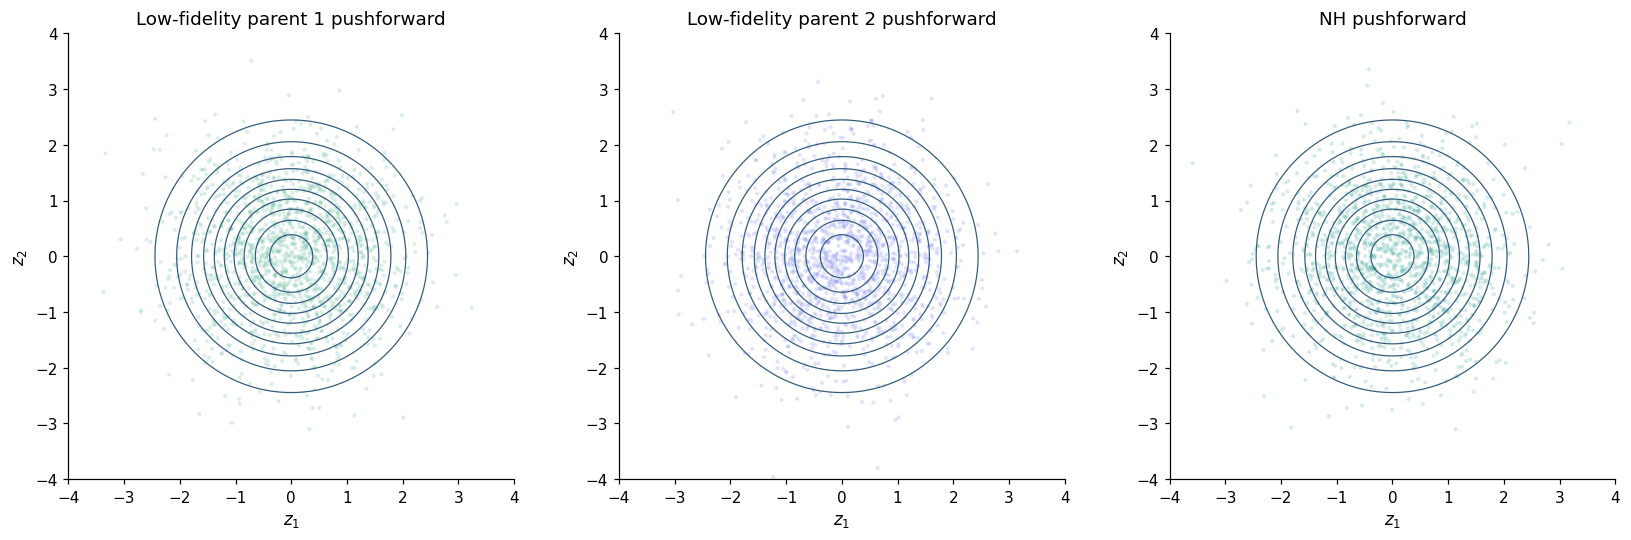

In [7]:
def map_summary(name, model, elapsed_seconds):
    z_hat = model.evaluate(x_0_test)
    exact_z = S_ell(x_0_test, **FIDELITY_PARAMS[0])
    recovered = model.inverse(z_hat[:512])
    round_trip_error = np.max(np.abs(recovered - x_0_test[:512]))
    assert round_trip_error < 1e-6
    return {"name": name, "coefficients": model.coefficients.flatten().size, "seconds": elapsed_seconds, "S_rmse": float(np.sqrt(np.mean((z_hat-exact_z)**2))), "round_trip_error": float(round_trip_error), "z_hat": z_hat}

summary = map_summary("Non-hierarchical map $\widehat{\boldsymbol{S}}^{\mathrm{NH}}$", S_hat_NH, training_seconds)
print(f"coefficients: {summary['coefficients']}; training: {summary['seconds']:.2f} s")
print(f"RMSE against exact HF transport: {summary['S_rmse']:.4f}")
print(f"max round-trip error: {summary['round_trip_error']:.2e}")
X_ell_test = [banana_sample(N_test, rng, **params) for params in FIDELITY_PARAMS[1:]]
parent_pushforwards = [parent_map.evaluate(samples) for parent_map, samples in zip(S_hat_NH.low_fidelity_maps, X_ell_test)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
for axis, pushed, title, color in zip(axes, parent_pushforwards + [summary["z_hat"]], ["Low-fidelity parent 1 pushforward", "Low-fidelity parent 2 pushforward", "NH pushforward"], [MIDDLE_FIDELITY_COLOR, LOW_FIDELITY_COLOR, LEARNED_COLOR]):
    axis.contour(x_xx, x_yy, reference_density, levels=10, colors="#315B7D", linewidths=0.8)
    axis.scatter(pushed[:N_display, 0], pushed[:N_display, 1], s=7, alpha=0.2, color=color, edgecolors="none")
    axis.set_title(title)
    style_joint_axis(axis, r"$z_1$", r"$z_2$", (-4.0, 4.0, -4.0, 4.0))
plt.show()


## 7. Unconditional target sampling via $(\widehat{\boldsymbol{S}}^{\mathrm{NH}})^{-1}$


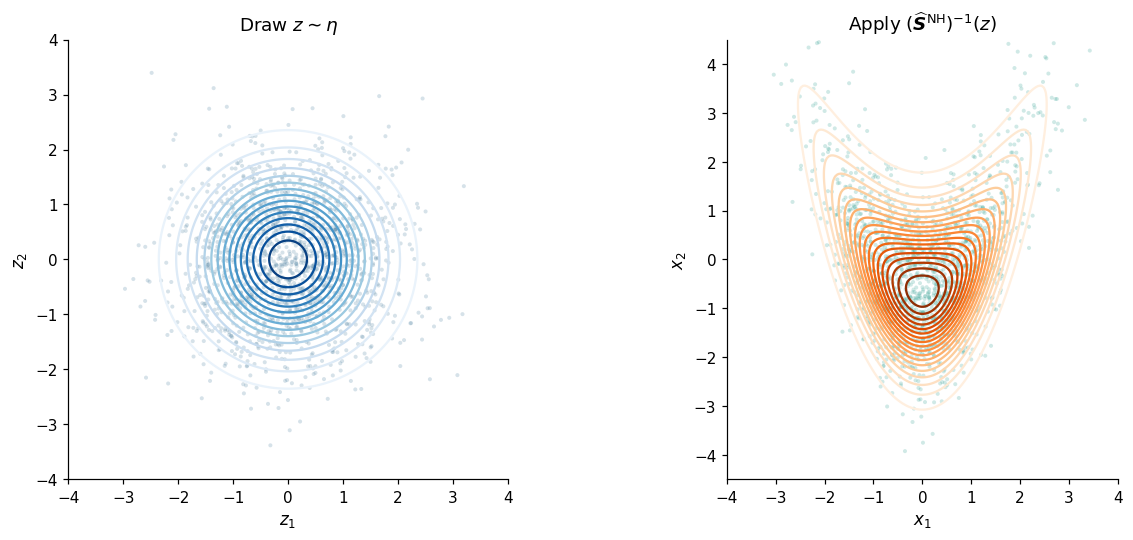

In [8]:
N_generate = 5000
sampling_seed = 404
sampling_rng = np.random.default_rng(sampling_seed)
z_draws = sampling_rng.standard_normal((N_generate, INPUT_DIM))
x_draws_from_inverse = S_hat_NH.inverse(z_draws)
x_draws_from_sample = S_hat_NH.sample(N_generate, random_state=sampling_seed)
assert np.allclose(x_draws_from_inverse, x_draws_from_sample)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
axes[0].contour(z_xx, z_yy, reference_density, levels=18, cmap="Blues")
axes[0].scatter(z_draws[:N_display, 0], z_draws[:N_display, 1], s=7, alpha=0.22, color=REFERENCE_COLOR, edgecolors="none")
axes[0].set_title(r"Draw $z\sim\eta$")
style_joint_axis(axes[0], r"$z_1$", r"$z_2$", (-4.0, 4.0, -4.0, 4.0))
axes[1].contour(x_xx, x_yy, true_target_densities[0], levels=18, cmap="Oranges")
axes[1].scatter(x_draws_from_inverse[:N_display, 0], x_draws_from_inverse[:N_display, 1], s=7, alpha=0.22, color=LEARNED_COLOR, edgecolors="none")
axes[1].set_title(r"Apply $(\widehat{\boldsymbol{S}}^{\mathrm{NH}})^{-1}(z)$")
style_joint_axis(axes[1])
plt.show()


## 8. Conditional sampling and conditional density

We condition on $X_1=1.0$ and compare the learned conditional with the analytic HF conditional.


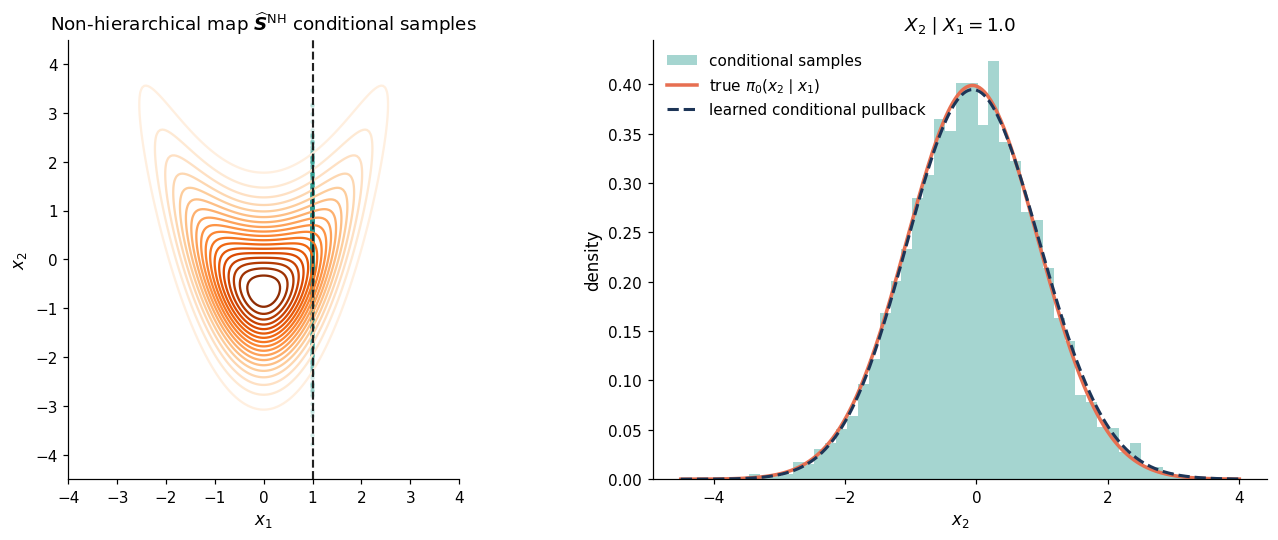

In [9]:
conditioned_x1 = 1.0
N_conditional = 5000
conditional_samples = S_hat_NH.conditional_sample(N_conditional, fixed_indices=[0], fixed_values=np.array([conditioned_x1]), random_state=808)
assert np.allclose(conditional_samples[:, 0], conditioned_x1)
x2_conditional_grid = np.linspace(-4.5, 4.0, 500)
conditional_grid = np.column_stack((np.full_like(x2_conditional_grid, conditioned_x1), x2_conditional_grid))
true_conditional_mean = FIDELITY_PARAMS[0]["bend"] * ((conditioned_x1 / FIDELITY_PARAMS[0]["scale_x"]) ** 2 - 1.0)
true_pi_0_conditional_density = normal_pdf_1d(x2_conditional_grid, mean=true_conditional_mean)
learned_pi_0_conditional_logdensity = S_hat_NH.conditional_pullback_logpdf(conditional_grid, fixed_indices=[0])
learned_pi_0_conditional_density = S_hat_NH.conditional_pullback_pdf(conditional_grid, fixed_indices=[0])
assert np.all(np.isfinite(learned_pi_0_conditional_logdensity))
assert np.all(np.isfinite(learned_pi_0_conditional_density)) and np.all(learned_pi_0_conditional_density >= 0.0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
axes[0].contour(x_xx, x_yy, true_target_densities[0], levels=18, cmap="Oranges")
axes[0].scatter(conditional_samples[:N_display, 0], conditional_samples[:N_display, 1], s=8, alpha=0.2, color=LEARNED_COLOR, edgecolors="none")
axes[0].axvline(conditioned_x1, color="#222222", linestyle="--", linewidth=1.4)
axes[0].set_title(r"Non-hierarchical map $\widehat{\boldsymbol{S}}^{\mathrm{NH}}$ conditional samples")
style_joint_axis(axes[0])
axes[1].hist(conditional_samples[:, 1], bins=45, density=True, alpha=0.42, color=LEARNED_COLOR, edgecolor="none", label="conditional samples")
axes[1].plot(x2_conditional_grid, true_pi_0_conditional_density, color=TARGET_COLOR, linewidth=2.3, label=r"true $\pi_0(x_2\mid x_1)$")
axes[1].plot(x2_conditional_grid, learned_pi_0_conditional_density, color="#1D3557", linestyle="--", linewidth=2.0, label="learned conditional pullback")
axes[1].set(title=rf"$X_2\mid X_1={conditioned_x1}$", xlabel=r"$x_2$", ylabel="density")
axes[1].legend(frameon=False)
plt.show()


## 9. The map-induced joint target density

`pullback_pdf(x)` evaluates $\widehat\pi_0(x)=\eta(\widehat{\boldsymbol{S}}^{\mathrm{NH}}(x))|\det\nabla\widehat{\boldsymbol{S}}^{\mathrm{NH}}(x)|$.


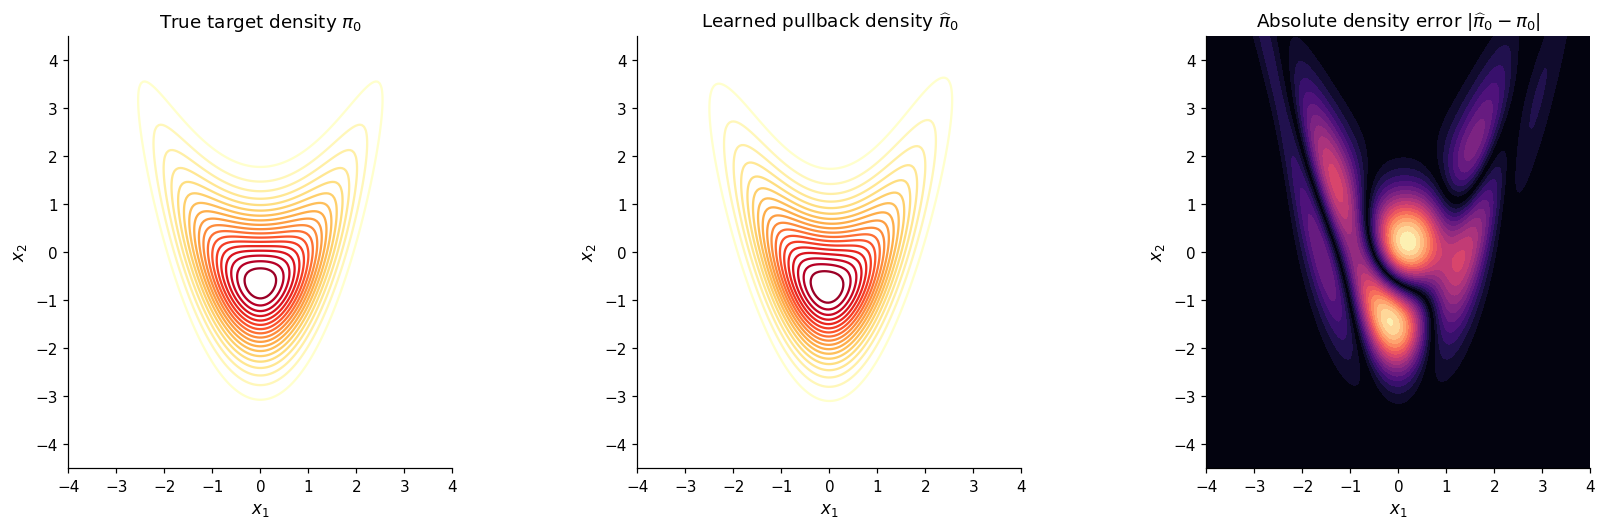

In [10]:
learned_pi_0_logdensity = S_hat_NH.pullback_logpdf(x_grid)
learned_pi_0_density = S_hat_NH.pullback_pdf(x_grid).reshape(x_xx.shape)
assert np.all(np.isfinite(learned_pi_0_logdensity))
assert np.all(np.isfinite(learned_pi_0_density)) and np.all(learned_pi_0_density >= 0.0)
absolute_density_error = np.abs(learned_pi_0_density - true_target_densities[0])
density_max = max(true_target_densities[0].max(), learned_pi_0_density.max())
density_levels = np.linspace(0.0, density_max, 20)[1:]
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.7), constrained_layout=True)
for axis, density, title in zip(axes[:2], [true_target_densities[0], learned_pi_0_density], [r"True target density $\pi_0$", r"Learned pullback density $\widehat\pi_0$"]):
    axis.contour(x_xx, x_yy, density, levels=density_levels, cmap="YlOrRd")
    axis.set_title(title)
    style_joint_axis(axis)
axes[2].contourf(x_xx, x_yy, absolute_density_error, levels=18, cmap="magma")
axes[2].set_title(r"Absolute density error $|\widehat\pi_0-\pi_0|$")
style_joint_axis(axes[2])
plt.show()


## 10. Math-to-API summary

| Task | Mathematical operation | `NonHierarchicalTriangularMap` call |
| --- | --- | --- |
| Configure peer parents and correction orders | parent maps plus coupled shift/scale/correction blocks | `NonHierarchicalMapParams(...)` |
| Train with parent corrections | pretrained parents plus trainable corrections applied to them | `train(use_corrections=True)` |
| Push target samples to reference | $\widehat{\boldsymbol{S}}^{\mathrm{NH}}(x)$ | `evaluate(x)` |
| Pull reference samples to target | $(\widehat{\boldsymbol{S}}^{\mathrm{NH}})^{-1}(z)$ | `inverse(z)` |
| Draw unconditional target samples | sample reference, then invert | `sample(...)` |
| Draw $X_2\mid X_1=a$ | clamp a leading coordinate while inverting | `conditional_sample(...)` |
| Evaluate learned densities | change of variables | `pullback_pdf(...)` / `conditional_pullback_pdf(...)` |
